### The Simplest Graph
Let's build a simple graph with 3 nodes and one conditional edge.


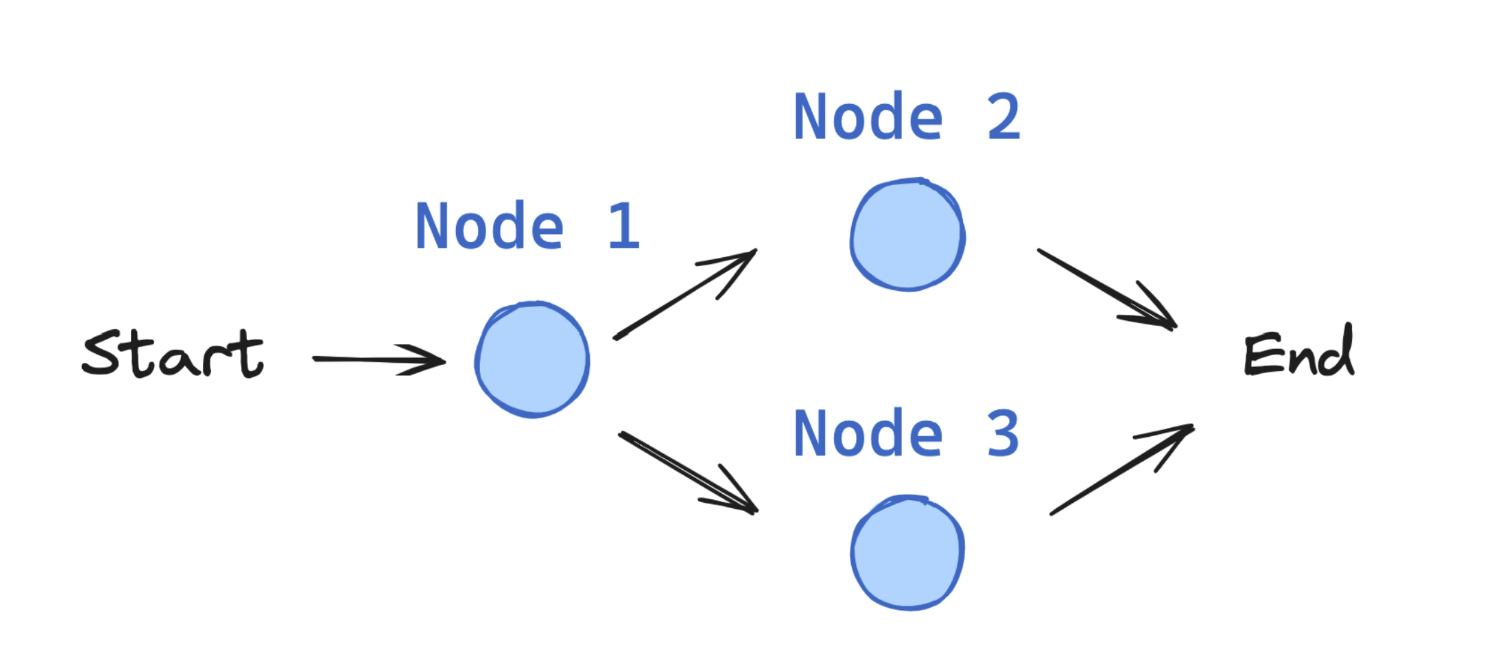

### **State**
The State schema serves as the input schema for all Nodes and Edges in the graph.\
The first thing you do when you define a graph is define the `State` of the graph. The State consists of the schema of the graph as well as `reducer` functions which specify how to apply updates to the state. The schema of the State will be the input schema to all `Nodes` and `Edges` in the graph, and can be either a `TypedDict` or a `Pydantic` model. All Nodes will emit updates to the State which are then applied using the specified reducer function.

Reference - [Graph API overview](https://docs.langchain.com/oss/python/langgraph/graph-api#state)

In [1]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_state: str

### **Nodes**
Nodes are just python functions.

The first positional argument is the state, as defined above.

Because the state is a TypedDict with schema as defined above, each node can access the `key`, `graph_state`, with `state['graph_state']`.

Each node returns a new value of the state key `graph_state`.

By default, the new value returned by each node will `override` the prior state value.

In [5]:
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}

### **Edges**
Edges connect the nodes.

`Normal Edges` are used if you want to always go from, for example, `node_1` to `node_2`.

`Conditional Edges` are used if you want to `optionally` route between nodes.

* Conditional edges are implemented as functions that return the next node to visit based on some logic.



In [6]:
import random
from typing import Literal

def decide_mood(state) -> Literal["node_2", "node_3"]:
    
    # Often, we will use state to decide on the next node to visit
    user_input = state['graph_state'] 
    
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:

        # 50% of the time, we return Node 2
        return "node_2"
    
    # 50% of the time, we return Node 3
    return "node_3"

`Literal` is a type hint that restricts a variable or function argument to specific, exact values rather than just a general data type. For example, instead of allowing any string (str), you can use Literal to specify that only the exact strings "read", "write", or "append" are acceptable

### **Graph Construction**
Now, we build the graph from our components defined above.

The StateGraph class is the graph class that we can use.

First, we initialize a StateGraph with the `State` class we defined above.

Then, we add our nodes and edges.

We use the `START` Node, a special node that sends user input to the graph, to indicate where to start our graph.

The `END` Node is a special node that represents a terminal node.

Finally, we compile our graph to perform a few basic checks on the graph structure.

We can visualize the graph as a Mermaid diagram.

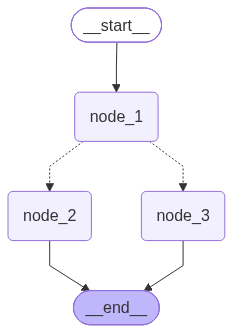

In [11]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

### **Graph Invocation**
The compiled graph implements the runnable protocol.

This provides a standard way to execute LangChain components.

`invoke` is one of the standard methods in this interface.

The input is a dictionary __`{"graph_state": "Hi, this is lance."}`__, which sets the initial value for our graph state dict.

When invoke is called, the graph starts execution from the `START` node.

It progresses through the defined nodes (`node_1`, `node_2`, `node_3`) in order.

The conditional edge will traverse from node 1 to node 2 or 3 using a 50/50 decision rule.

Each node function receives the current state and returns a new value, which overrides the graph state.

The execution continues until it reaches the END node.

In [13]:
graph.invoke({"graph_state" : "Hi, this is Shekh Abdullah Ayubi."})

---Node 1---
---Node 2---


{'graph_state': 'Hi, this is Shekh Abdullah Ayubi. I am happy!'}

`invoke` runs the entire graph __synchronously__.

This waits for each step to complete before moving to the next.

It returns the final state of the graph after all nodes have executed.